# Category RSA geometry — patient vs. control (Fig 10)

Same RDM spheres. OTC patients only (last session); controls (first session); exclude sub-017, (sub-108, ses-02). Split by intact hemisphere, never pooled. `hemi='l'` = LH-intact patients vs controls' left; `hemi='r'` = RH-intact vs controls' right. Cohort: n=25 (13 LH-intact / 12 RH-intact) + 38 controls.

`fisher_r` stored as Fisher-z; model z directly, `tanh` -> r for figures only. Negative r = distinct voxel patterns (legitimate; betas/z signs not interpreted).

**Two measures, coarse -> fine:**
1. **Geometry, holistic** (omnibus): does the 6-value RDM differ by group? LMM `fisher_r ~ C(pair)*C(group)`, 5-df Wald on the interaction. This is the inferential gate.
2. **Geometry, pairwise** (post-hoc): which of the 6 pairs moved? 10k label-shuffle perm, Cohen's d, BH-FDR within ROI x hemi. Interpreted only where the omnibus is significant.

**Distinctiveness is not computed here.** It is reported from the ComBat-harmonized pipeline (`figures_harmonized.ipynb`, `stats_results_harmonized_corrected.csv`). The unharmonized version previously in this notebook was a duplicate and has been removed.


## 1. Setup

In [36]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.spatial import procrustes
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

sys.path.insert(0, "/user_data/csimmon2/git_repos/sym_pt")
from sym_pt_params import processed_dir

np.random.seed(0)
RSA_CSV     = Path("/user_data/csimmon2/git_repos/sym_pt/D_liu/rsa_v1_harmonized.csv")
FIG_DIR     = Path("/user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact")
FIG_DIR.mkdir(parents=True, exist_ok=True)
ROIS        = ["face_FFA", "house_PPA", "object_LOC", "word_VWFA"]
CATS4       = ["face", "object", "house", "word"]
N_PERM      = 10_000
HEMIS       = {"l": "left", "r": "right"}
EXCLUDE     = ["sub-017"]
EXCLUDE_SES = [("sub-108", 2)]
CAT_COLORS  = {"face": "#378ADD", "house": "#D85A30",
               "object": "#639922", "word": "#EF9F27"}
print("RSA_CSV:", RSA_CSV, "| exists:", RSA_CSV.exists())
print("FIG_DIR:", FIG_DIR)

RSA_CSV: /user_data/csimmon2/git_repos/sym_pt/D_liu/rsa_v1_harmonized.csv | exists: True
FIG_DIR: /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact


## 2. Load + cohort/session filter
OTC -> last session; controls -> first session.

In [37]:
mni = pd.read_csv(RSA_CSV)
mni = mni[~mni["subject_id"].isin(EXCLUDE)].copy()
mni["ses_num"] = pd.to_numeric(mni["session"], errors="coerce").astype("Int64")
for bad_sub, bad_ses in EXCLUDE_SES:
    mni = mni[~((mni["subject_id"] == bad_sub) & (mni["ses_num"] == bad_ses))]
mni = mni[mni["category"].isin(ROIS) & mni["pair"].notna()].copy()

ls = (mni[mni["group"] == "OTC"].groupby("subject_id")["ses_num"].max()
        .reset_index().rename(columns={"ses_num": "keep"}))
pt = mni[mni["group"] == "OTC"].merge(ls, on="subject_id")
pt = pt[pt["ses_num"] == pt["keep"]].drop(columns="keep")
fs = (mni[mni["status"] == "control"].groupby("subject_id")["ses_num"].min()
        .reset_index().rename(columns={"ses_num": "keep"}))
ct = mni[mni["status"] == "control"].merge(fs, on="subject_id")
ct = ct[ct["ses_num"] == ct["keep"]].drop(columns="keep")
df = pd.concat([pt, ct], ignore_index=True)

df["pair_sorted"] = df["pair"].apply(lambda p: "-".join(sorted(p.split("-"))))
PAIRS_SORTED = sorted(df["pair_sorted"].unique())
assert len(PAIRS_SORTED) == 6, f"expected 6 pairs, got {PAIRS_SORTED}"
df = df.drop(columns=["pair"])
df["is_pt"] = (df["status"] == "patient").astype(int)

print("patients:", df[df.is_pt == 1]["subject_id"].nunique(),
      "| controls:", df[df.is_pt == 0]["subject_id"].nunique())
print(df.groupby(["category", "hemi", "status"])["subject_id"].nunique().unstack(fill_value=0))

patients: 25 | controls: 38
status           control  patient
category   hemi                  
face_FFA   l          38       13
           r          38       12
house_PPA  l          38       13
           r          38       12
object_LOC l          38       13
           r          38       12
word_VWFA  l          38       13
           r          38       12


## 3. Helpers

In [38]:
def stratum(df, roi, hemi):
    s = df[(df["category"] == roi) & (df["hemi"] == hemi)].copy()
    s["group"] = np.where(s["is_pt"] == 1, "patient", "control")
    return s

def cohen_d(x, y):
    nx, ny = len(x), len(y)
    sp = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
    return np.nan if sp == 0 else (np.mean(x) - np.mean(y)) / sp

def perm_test(x, y, n=N_PERM, rng=None):
    rng = rng or np.random.default_rng(0)
    obs = np.mean(x) - np.mean(y)
    pool = np.concatenate([x, y]); nx = len(x)
    null = np.empty(n)
    for i in range(n):
        rng.shuffle(pool); null[i] = np.mean(pool[:nx]) - np.mean(pool[nx:])
    return obs, (np.sum(np.abs(null) >= abs(obs)) + 1) / (n + 1)

def bh_fdr(p):
    p = np.asarray(p, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 1.0
    for k in range(m-1, -1, -1):
        i = order[k]; run = min(run, p[i] * m / (k+1)); adj[i] = run
    return adj

def subj_rdm(sub_rows):
    M = np.eye(4)
    for _, row in sub_rows.iterrows():
        a, b = row["pair_sorted"].split("-"); i, j = CATS4.index(a), CATS4.index(b)
        M[i, j] = M[j, i] = np.tanh(row["fisher_r"])
    return M

def coords(sim_mat):
    M = np.where(np.isnan(sim_mat), 0.0, sim_mat)
    np.fill_diagonal(M, 1.0)
    return MDS(n_components=2, dissimilarity="precomputed", random_state=0
               ).fit_transform(1.0 - M)

def subj_mats(s, grp):
    return {sid: subj_rdm(g) for sid, g in s[s.group == grp].groupby("subject_id")
            if g["pair_sorted"].nunique() == 6}

def mean_rdm(s, grp):
    mats = list(subj_mats(s, grp).values())
    return (np.nanmean(np.stack(mats), axis=0), len(mats)) if mats else (np.full((4, 4), np.nan), 0)

## 4. Geometry — holistic (omnibus)
Does the full 6-value RDM differ by group? MixedLM, subject random intercept; 5-df joint Wald on `C(pair_sorted):C(group)`.

In [39]:
omni = []
for roi in ROIS:
    for hemi in HEMIS:
        s = stratum(df, roi, hemi).dropna(subset=["fisher_r", "group", "pair_sorted"]).reset_index(drop=True)
        npt = int((s.group == "patient").groupby(s.subject_id).any().sum())
        nct = int((s.group == "control").groupby(s.subject_id).any().sum())
        if npt < 2 or nct < 2:
            omni.append(dict(roi=roi, hemi=hemi, n_pt=npt, n_ct=nct,
                             df=np.nan, chi2=np.nan, p=np.nan)); continue
        m = smf.mixedlm("fisher_r ~ C(pair_sorted) * C(group)", s, groups=s["subject_id"]).fit(reml=True)
        inter = [t for t in m.params.index if (":" in t and "C(pair_sorted)" in t and "C(group)" in t)]
        R = np.zeros((len(inter), len(m.params)))
        for i, t in enumerate(inter):
            R[i, list(m.params.index).index(t)] = 1.0
        w = m.wald_test(R, scalar=True)
        omni.append(dict(roi=roi, hemi=hemi, n_pt=npt, n_ct=nct, df=int(len(inter)),
                         chi2=float(np.squeeze(w.statistic)), p=float(np.squeeze(w.pvalue))))
omni = pd.DataFrame(omni)
omni

,roi,hemi,n_pt,n_ct,df,chi2,p
0,face_FFA,l,13,38,5,12.328892,3.054879e-02
1,face_FFA,r,12,37,5,44.278304,2.033637e-08
2,house_PPA,l,13,38,5,3.711048,5.917206e-01
3,house_PPA,r,12,38,5,10.658624,5.858470e-02
4,object_LOC,l,13,38,5,6.359672,2.727771e-01
5,object_LOC,r,12,38,5,13.324045,2.052415e-02
6,word_VWFA,l,13,37,5,4.949340,4.220941e-01
7,word_VWFA,r,12,37,5,31.368721,7.920837e-06


## 5. Geometry — pairwise (post-hoc)
Which of the 6 pairs moved? 10k label-shuffle perm, Cohen's d, BH-FDR within ROI x hemi. Survivors under a *null* omnibus are exploratory, not interpreted.

In [40]:
rng = np.random.default_rng(0)
rows = []
for roi in ROIS:
    for hemi in HEMIS:
        s = stratum(df, roi, hemi)
        block = []
        for pr in PAIRS_SORTED:
            sp = s[s["pair_sorted"] == pr]
            x = sp.loc[sp.group == "patient", "fisher_r"].dropna().values
            y = sp.loc[sp.group == "control", "fisher_r"].dropna().values
            if len(x) < 2 or len(y) < 2:
                block.append(dict(roi=roi, hemi=hemi, pair=pr, n_pt=len(x), n_ct=len(y),
                                  diff=np.nan, d=np.nan, p=np.nan)); continue
            diff, p = perm_test(x, y, rng=rng)
            block.append(dict(roi=roi, hemi=hemi, pair=pr, n_pt=len(x), n_ct=len(y),
                              diff=diff, d=cohen_d(x, y), p=p))
        b = pd.DataFrame(block)
        b["p_fdr"] = bh_fdr(b["p"].fillna(1.0).values)
        b["survives"] = (b["p_fdr"] < .05) & b["p"].notna()
        rows.append(b)
posthoc = pd.concat(rows, ignore_index=True)
posthoc.round(4)

,roi,hemi,pair,n_pt,n_ct,diff,d,p,p_fdr,survives
0,face_FFA,l,face-house,13,38,-0.1081,-0.2641,0.4085,0.5839,False
1,face_FFA,l,face-object,13,38,-0.2013,-0.5850,0.0769,0.2307,False
2,face_FFA,l,face-word,13,38,-0.3428,-1.0101,0.0030,0.0180,True
3,face_FFA,l,house-object,13,38,-0.1696,-0.3431,0.2838,0.5675,False
4,face_FFA,l,house-word,13,38,0.1076,0.2242,0.4866,0.5839,False
5,face_FFA,l,object-word,13,38,-0.0255,-0.0639,0.8426,0.8426,False
6,face_FFA,r,face-house,12,37,-0.1347,-0.3268,0.3298,0.3957,False
7,face_FFA,r,face-object,12,37,0.0644,0.1663,0.6172,0.6172,False
8,face_FFA,r,face-word,12,37,0.6143,1.5317,0.0001,0.0006,True
9,face_FFA,r,house-object,12,37,-0.2250,-0.4714,0.1617,0.3234,False


## 6. Survivors

In [41]:
surv = posthoc[posthoc["survives"]].copy()
if len(surv):
    print(surv[["roi", "hemi", "pair", "diff", "d", "p", "p_fdr"]].round(4).to_string(index=False))
else:
    print("No pairs survive BH-FDR; report the omnibus with effect sizes, frame as power-limited.")

      roi hemi        pair    diff       d      p  p_fdr
 face_FFA    l   face-word -0.3428 -1.0101 0.0030 0.0180
 face_FFA    r   face-word  0.6143  1.5317 0.0001 0.0006
 face_FFA    r object-word  0.3872  0.8859 0.0105 0.0315
house_PPA    l face-object -0.5803 -1.3657 0.0001 0.0006
house_PPA    l object-word -0.5529 -1.2410 0.0002 0.0006
word_VWFA    r  house-word  0.6424  1.1626 0.0011 0.0066
word_VWFA    r object-word  0.4431  0.9082 0.0089 0.0267


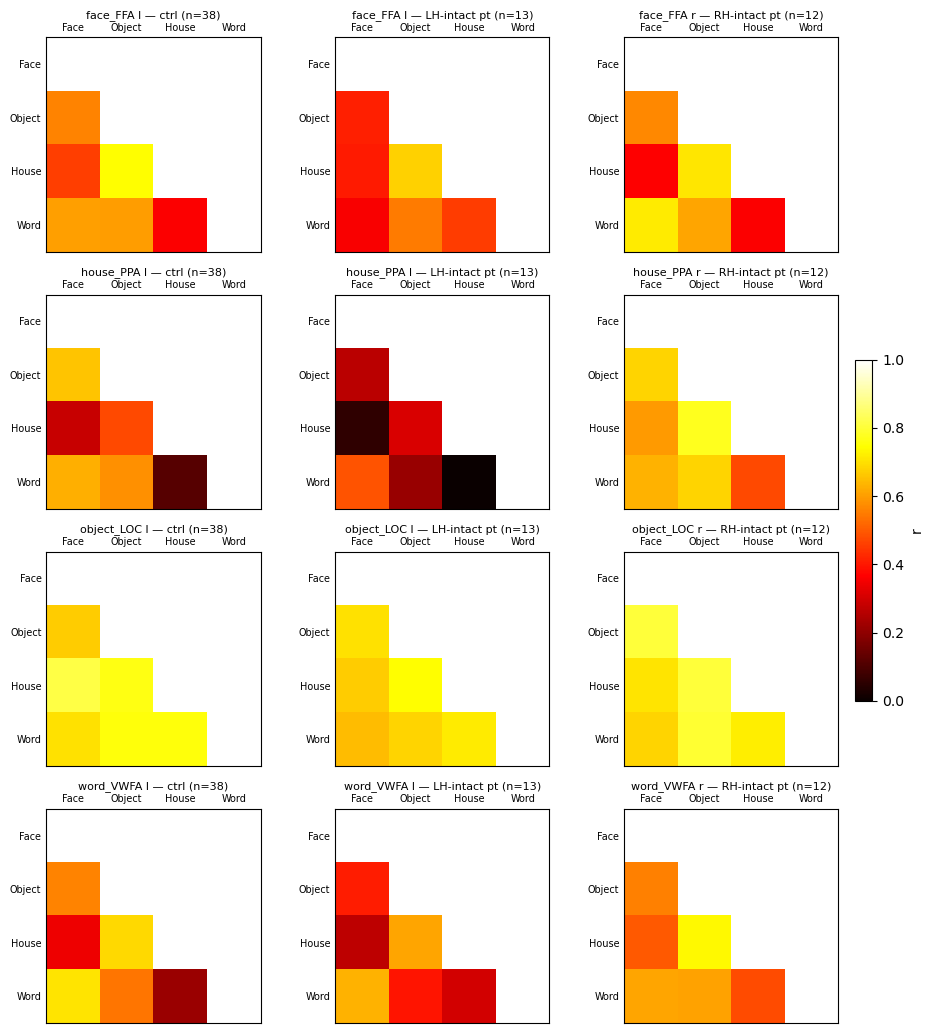

In [42]:
# ─── Exploratory: all-ROI RDM grid (ctrl | LH-intact pt | RH-intact pt) ───
LAB = ["Face", "Object", "House", "Word"]
fig, axes = plt.subplots(len(ROIS), 3, figsize=(11, 3.2*len(ROIS)))
for ri, roi in enumerate(ROIS):
    sl = stratum(df, roi, "l"); sr = stratum(df, roi, "r")
    panels = [(mean_rdm(sl, "control"), f"{roi} l — ctrl"),
              (mean_rdm(sl, "patient"), f"{roi} l — LH-intact pt"),
              (mean_rdm(sr, "patient"), f"{roi} r — RH-intact pt")]
    for ci, ((M, nrdm), ttl) in enumerate(panels):
        ax = axes[ri, ci]
        M = np.where(np.triu(np.ones_like(M, bool), k=1), np.nan, M)
        im = ax.imshow(M, cmap="hot", vmin=0, vmax=1)
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
        ax.set_xticklabels(LAB, fontsize=7); ax.set_yticklabels(LAB, fontsize=7)
        ax.xaxis.tick_top(); ax.set_title(f"{ttl} (n={nrdm})", fontsize=8, pad=14)
        ax.tick_params(length=0)
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="r")
plt.show()

## 7. Figure 10 — RDM triptych
Per selected ROI x hemi: control mean, patient mean, and the difference. Asterisks mark pairs surviving BH-FDR. Suptitle carries the omnibus χ²(5).

Note: χ² and the asterisks are recomputed in this notebook, not read from `stats_results_harmonized_corrected.csv` — cross-check before quoting in the MS.

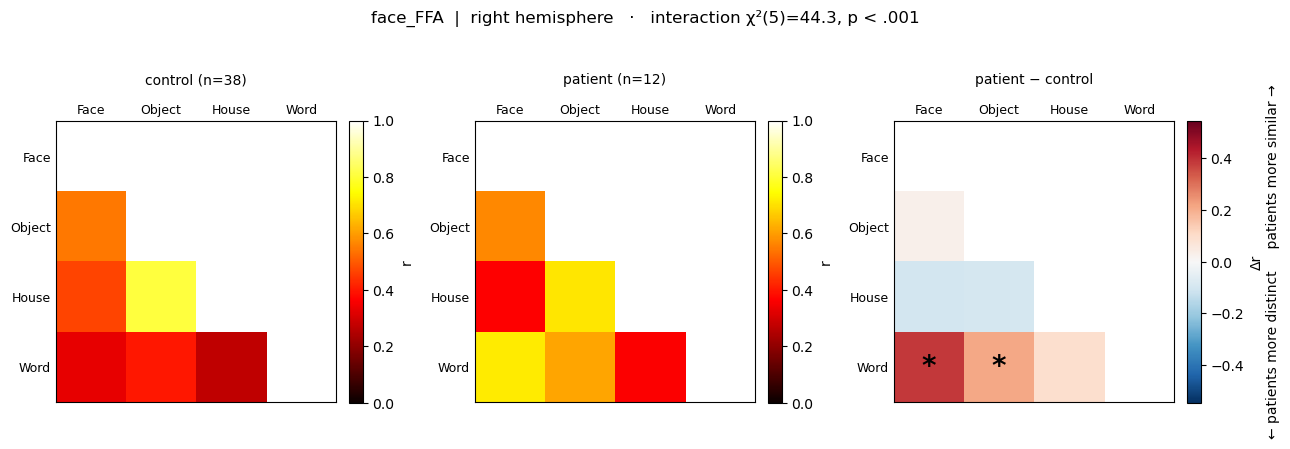

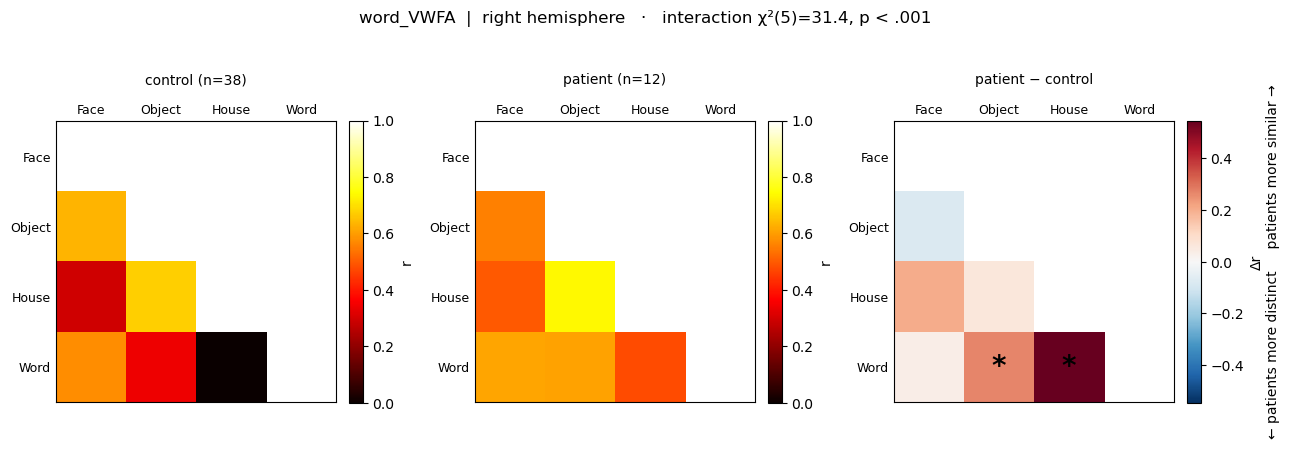

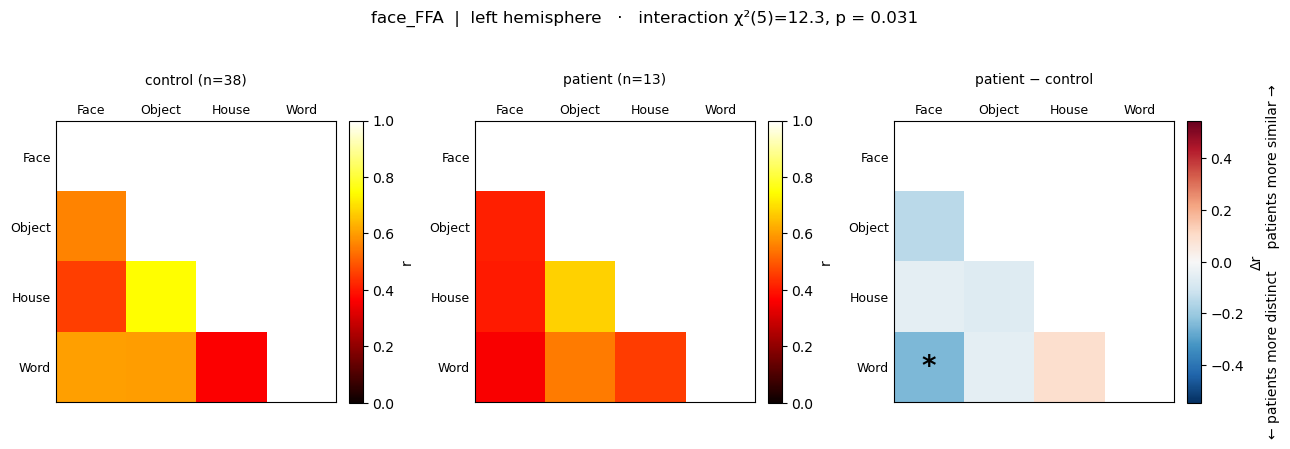

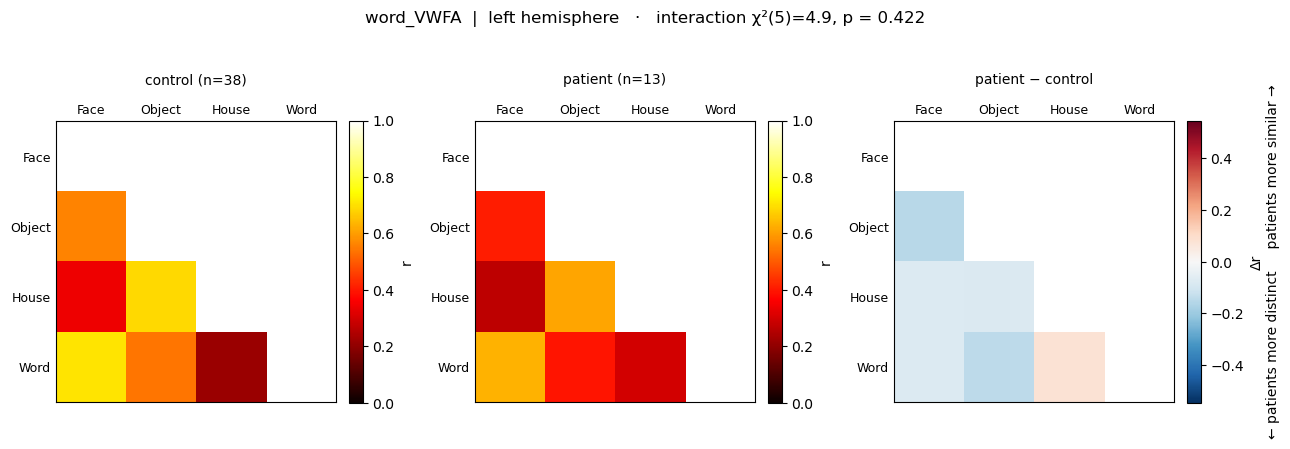

In [45]:
# ─── Fig 10: RDM triptych (ctrl | patient | difference) per selected ROI ──
LAB = ["Face", "Object", "House", "Word"]
PLOT = [("face_FFA", "r"), ("word_VWFA", "r"), ("face_FFA", "l"), ("word_VWFA", "l")]

def _mask_upper(M):
    return np.where(np.triu(np.ones_like(M, bool), k=1), np.nan, M)

# global symmetric scale across all difference panels
dmax = 0.0
for roi, hemi in PLOT:
    s = stratum(df, roi, hemi)
    C, _ = mean_rdm(s, "control"); P, _ = mean_rdm(s, "patient")
    D = P - C; np.fill_diagonal(D, np.nan)
    if np.isfinite(D).any():
        dmax = max(dmax, np.nanmax(np.abs(D)))

def plot_rdm_diff(roi, hemi, gdmax):
    s = stratum(df, roi, hemi)
    C, nc = mean_rdm(s, "control")
    P, npt = mean_rdm(s, "patient")
    D = P - C
    np.fill_diagonal(D, np.nan)

    o = omni[(omni.roi == roi) & (omni.hemi == hemi)].iloc[0]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))

    specs = [(_mask_upper(C), f"control (n={nc})", "hot", 0, 1, "r"),
             (_mask_upper(P), f"patient (n={npt})", "hot", 0, 1, "r"),
             (_mask_upper(D), "patient − control", "RdBu_r", -gdmax, gdmax, "Δr")]
    
    DIFF_LAB = "Δr\n← patients more distinct     patients more similar →"
    specs = [(_mask_upper(C), f"control (n={nc})", "hot", 0, 1, "r"),
             (_mask_upper(P), f"patient (n={npt})", "hot", 0, 1, "r"),
             (_mask_upper(D), "patient − control", "RdBu_r", -gdmax, gdmax, DIFF_LAB)]
    for ax, (M, ttl, cmap, vmin, vmax, cbar_lab) in zip(axes, specs):
        im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
        ax.set_xticklabels(LAB, fontsize=9); ax.set_yticklabels(LAB, fontsize=9)
        ax.xaxis.tick_top(); ax.tick_params(length=0)
        ax.set_title(ttl, fontsize=10, pad=14)
        if cbar_lab == DIFF_LAB:
            for pr in PAIRS_SORTED:
                row = posthoc[(posthoc.roi == roi) & (posthoc.hemi == hemi) & (posthoc.pair == pr)]
                if len(row) and bool(row["survives"].iloc[0]):
                    a, b = pr.split("-"); i, j = LAB.index(a.title()), LAB.index(b.title())
                    lo, hi = max(i, j), min(i, j)
                    ax.text(hi, lo, "*", ha="center", va="center", color="black",
                            fontsize=20, fontweight="bold")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_lab)

    p_str = "p < .001" if o["p"] < .001 else f"p = {o['p']:.3f}"
    fig.suptitle(f'{roi}  |  {HEMIS[hemi]} hemisphere   ·   '
                 f'interaction χ²(5)={o["chi2"]:.1f}, {p_str}',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"rdm_diff_{roi}_{hemi}.png", dpi=300, bbox_inches="tight")
    plt.show()

for roi, hemi in PLOT:
    plot_rdm_diff(roi, hemi, dmax)

## 8. Values for write-up

In [44]:
# ─── Results values for write-up ─────────────────────────────────────────
# NOTE: distinctiveness is NOT reported from this notebook. Use the
# harmonized pipeline (figures_harmonized.ipynb / stats_results_harmonized_corrected.csv).
print("=" * 60); print("GEOMETRY OMNIBUS — interaction (pair × group, Wald χ²)"); print("=" * 60)
print(omni[["roi", "hemi", "n_pt", "n_ct", "df", "chi2", "p"]].round(6).to_string(index=False))

print("\n" + "=" * 60); print("GEOMETRY PAIRWISE — perm, BH-FDR within ROI×hemi"); print("=" * 60)
print(posthoc[["roi", "hemi", "pair", "n_pt", "n_ct", "diff", "d", "p", "p_fdr", "survives"]]
      .round(4).to_string(index=False))

print("\n" + "=" * 60); print("PROCRUSTES DISPARITY — perm (controls leave-one-out)"); print("=" * 60)
disp_rows = []
for roi in ROIS:
    for hemi in HEMIS:
        s = stratum(df, roi, hemi)
        ctrl = subj_mats(s, "control"); pat = subj_mats(s, "patient")
        if len(ctrl) < 2 or len(pat) < 1:
            continue
        cmats = np.stack(list(ctrl.values())); cm = coords(np.nanmean(cmats, axis=0))
        cd, pdd = [], []
        for k, sid in enumerate(ctrl):
            loo = np.nanmean(np.delete(cmats, k, axis=0), axis=0)
            _, _, dd = procrustes(coords(loo), coords(ctrl[sid])); cd.append(dd)
        for sid, M in pat.items():
            _, _, dd = procrustes(cm, coords(M)); pdd.append(dd)
        diff, p = perm_test(np.array(pdd), np.array(cd), rng=np.random.default_rng(0))
        disp_rows.append(dict(roi=roi, hemi=hemi, mean_ct=np.mean(cd),
                              mean_pt=np.mean(pdd), diff=diff, p=p))
print(pd.DataFrame(disp_rows).round(4).to_string(index=False))

GEOMETRY OMNIBUS — interaction (pair × group, Wald χ²)
       roi hemi  n_pt  n_ct  df      chi2        p
  face_FFA    l    13    38   5 12.328892 0.030549
  face_FFA    r    12    37   5 44.278304 0.000000
 house_PPA    l    13    38   5  3.711048 0.591721
 house_PPA    r    12    38   5 10.658624 0.058585
object_LOC    l    13    38   5  6.359672 0.272777
object_LOC    r    12    38   5 13.324045 0.020524
 word_VWFA    l    13    37   5  4.949340 0.422094
 word_VWFA    r    12    37   5 31.368721 0.000008

GEOMETRY PAIRWISE — perm, BH-FDR within ROI×hemi
       roi hemi         pair  n_pt  n_ct    diff       d      p  p_fdr  survives
  face_FFA    l   face-house    13    38 -0.1081 -0.2641 0.4085 0.5839     False
  face_FFA    l  face-object    13    38 -0.2013 -0.5850 0.0769 0.2307     False
  face_FFA    l    face-word    13    38 -0.3428 -1.0101 0.0030 0.0180      True
  face_FFA    l house-object    13    38 -0.1696 -0.3431 0.2838 0.5675     False
  face_FFA    l   house-word   